In [1]:
import urllib.request

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"

urllib.request.urlretrieve(url, "spam_dataset.zip")

print("Dataset downloaded successfully!")

Dataset downloaded successfully!


In [2]:
import zipfile

with zipfile.ZipFile("spam_dataset.zip", "r") as zip_ref:
    zip_ref.extractall("spam_dataset")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [3]:
import os

print(os.listdir("spam_dataset"))

['SMSSpamCollection', 'readme']


In [4]:
import pandas as pd

In [5]:
data = pd.read_csv(
    'spam_dataset/SMSSpamCollection',
    sep='\t',
    names=['label', 'message']
)

data.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
print(data.shape)

(5572, 2)


In [7]:
print(data['label'].value_counts())

label
ham     4825
spam     747
Name: count, dtype: int64


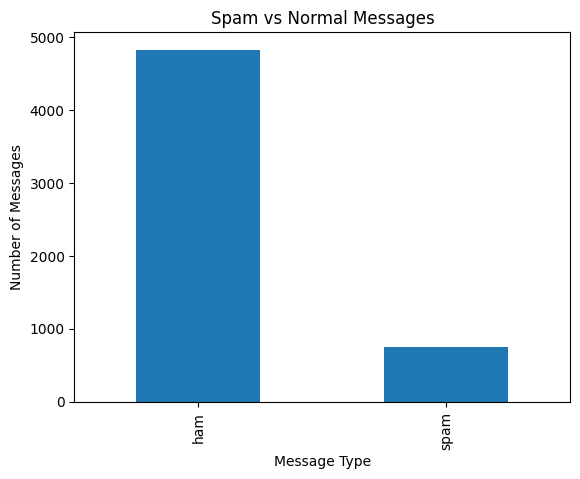

In [8]:
import matplotlib.pyplot as plt

data['label'].value_counts().plot(kind='bar')

plt.title('Spam vs Normal Messages')
plt.xlabel('Message Type')
plt.ylabel('Number of Messages')

plt.show()

In [10]:
data['label_num'] = data['label'].map({
    'ham': 0,
    'spam': 1
})

In [11]:
data.head()


,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [12]:
X = data['message']

In [13]:
y = data['label_num']

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words='english'
)

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

In [16]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

In [17]:
model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [18]:
y_pred = model.predict(X_test_tfidf)

In [19]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy: 0.9704035874439462
Accuracy Percentage: 97.04035874439462 %


In [20]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=['Not Spam', 'Spam']
))

              precision    recall  f1-score   support

    Not Spam       0.97      1.00      0.98       966
        Spam       1.00      0.78      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[966   0]
 [ 33 116]]


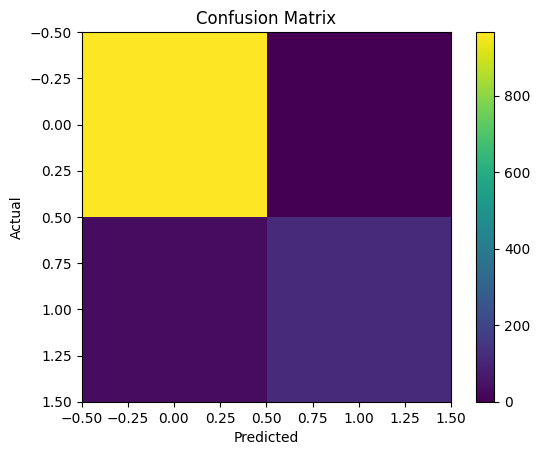

In [22]:
plt.imshow(cm)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.colorbar()
plt.show()

In [23]:
message = ["Congratulations! You have won a free prize. Claim your reward now!"]

message_tfidf = vectorizer.transform(message)

prediction = model.predict(message_tfidf)

if prediction[0] == 1:
    print("SPAM")
else:
    print("NOT SPAM")

SPAM


In [24]:
message = ["Hey, are you coming to college tomorrow?"]

message_tfidf = vectorizer.transform(message)

prediction = model.predict(message_tfidf)

if prediction[0] == 1:
    print("SPAM")
else:
    print("NOT SPAM")

NOT SPAM


In [25]:
def check_message(message):

    message_tfidf = vectorizer.transform([message])

    prediction = model.predict(message_tfidf)

    if prediction[0] == 1:
        return "SPAM"
    else:
        return "NOT SPAM"

In [26]:
check_message("You have won a free lottery prize!")

'SPAM'